In [8]:
import pandas as pd
import seaborn as sns

In [20]:
omegas = pd.read_table("../data/bladder/omega.flagged_annotated.tsv")
omegas.head()

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,flagged,flag_reason
0,EP300--HAT_KAT11,P19_0052_BTR_01,missense,24,7.687498,0.000000,4.960262,11.323363,False,NaN
1,EP300--HAT_KAT11,P19_0052_BTR_01,nonsense,1,3.850000,0.271178,0.219063,17.162378,False,NaN
2,EP300--HAT_KAT11,P19_0052_BTR_01,essential_splice,1,7.443651,0.131117,0.423787,33.104662,False,NaN
3,EP300--HAT_KAT11,P19_0052_BTR_01,truncating,2,5.063281,0.070808,0.838437,15.782886,False,NaN
4,EP300--HAT_KAT11,P19_0052_BTR_01,nonsynonymous_splice,26,7.400049,0.000000,4.860622,10.754541,False,NaN


In [21]:
reduced_omegas = omegas[(omegas["gene"].isin(["TP53", "RBM10"]))
                            & (omegas["sample"].isin(['CallerDeepumicaller', 'CallerDupcaller']))
                            & (omegas["impact"].isin(['missense', 'truncating']))
                            ]
reduced_omegas

,gene,sample,impact,mutations,dnds,pvalue,lower,upper,flagged,flag_reason
421,RBM10,CallerDeepumicaller,missense,140,4.689063,0.000000,3.871712,5.639380,False,NaN
424,RBM10,CallerDeepumicaller,truncating,339,65.275391,0.000000,55.645320,76.460083,False,NaN
597,TP53,CallerDeepumicaller,missense,48,4.795313,0.000000,3.514283,6.379785,False,NaN
600,TP53,CallerDeepumicaller,truncating,5,3.264063,0.027920,1.161156,7.119653,False,NaN
1243,RBM10,CallerDupcaller,missense,280,2.572656,0.000000,2.222919,2.969385,False,NaN
1246,RBM10,CallerDupcaller,truncating,504,27.848438,0.000000,24.196172,32.053149,False,NaN
1536,TP53,CallerDupcaller,missense,84,3.674976,0.000000,2.895631,4.605151,False,NaN
1539,TP53,CallerDupcaller,truncating,8,2.520313,0.024903,1.140131,4.766406,False,NaN


In [41]:
# horizontal barplot
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


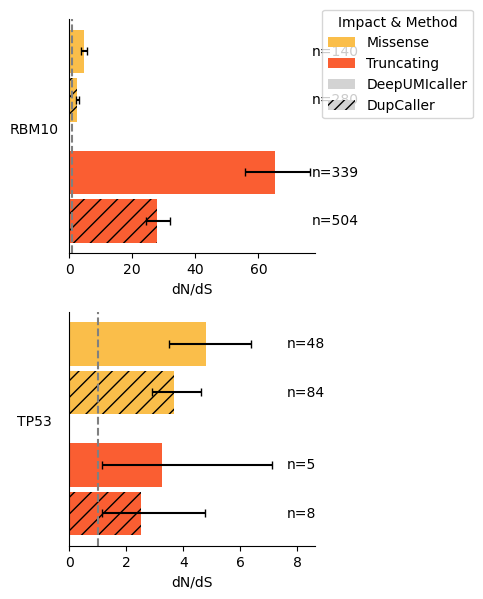

In [49]:
# Create figure with independent x-axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6))

# Define common parameters
# palette = {"truncating": "#FB8E6F", "missense": "#FBD180"}
palette = {"truncating": "#FA5E32", "missense": "#FABE4A"}


# Helper function to style bars
def style_gene_plot(ax, data, gene_name):
    # Standardize data order: impacts grouped together, callers within groups
    plot_data = data.sort_values(['impact', 'sample'])
    
    # Use gap to separate impact groups
    sns.barplot(
        y="impact", x="dnds", data=plot_data,
        hue="sample", palette={"CallerDeepumicaller": "#cccccc", "CallerDupcaller": "#cccccc"},
        ax=ax, gap=0.1
    )
    
    # Determine the maximum x value to align text
    # Max of (dnds, upper) across the whole subplot
    max_x = max(plot_data['upper'].fillna(plot_data['dnds']).max(), plot_data['dnds'].max())
    text_x_pos = max_x + 0.5 # Add padding
    
    num_categories = 2 # missense, truncating
    num_hues = 2       # Deep, Dup
    bars = ax.patches
    
    # We iterate and assign attributes based on data indices
    for hue_idx in range(num_hues):
        sample_name = plot_data['sample'].unique()[hue_idx]
        for cat_idx in range(num_categories):
            impact_name = plot_data['impact'].unique()[cat_idx]
            
            # Find the actual bar patch. Seaborn 0.13 logic for hue:
            bar = bars[hue_idx * num_categories + cat_idx]
            
            # Apply Style
            bar.set_facecolor(palette[impact_name])
            if "Dupcaller" in sample_name:
                bar.set_hatch('//')
            
            # Mutation Count Text
            row = plot_data[(plot_data['impact'] == impact_name) & (plot_data['sample'] == sample_name)]
            if not row.empty:
                count = row['mutations'].values[0]
                lower = row['lower'].values[0]
                upper = row['upper'].values[0]
                dnds = row['dnds'].values[0]
                
                # Add Error Bars (Confidence Intervals)
                if not (pd.isna(lower) or pd.isna(upper)):
                    xerr = [[max(0, dnds - lower)], [max(0, upper - dnds)]]
                    ax.errorbar(dnds, bar.get_y() + bar.get_height()/2, xerr=xerr, 
                                fmt='none', ecolor='black', capsize=3)

                # Mutation Count Text (aligned to the right)
                ax.text(text_x_pos, bar.get_y() + bar.get_height()/2, f'n={count}', 
                         va='center', ha='left', fontsize=10)

    ax.axvline(x=1, color='grey', linestyle='--')
    ax.set_ylabel(gene_name, rotation = 0, labelpad=25)
    ax.set_xlabel('dN/dS')
    ax.set_yticks([])
    # Adjust x-limits to accommodate the right-aligned text
    ax.set_xlim(right=text_x_pos + 1.0)
    if ax.get_legend(): ax.get_legend().remove()

# Execute for both genes
style_gene_plot(ax1, reduced_omegas[reduced_omegas["gene"] == "RBM10"], "RBM10")
style_gene_plot(ax2, reduced_omegas[reduced_omegas["gene"] == "TP53"], "TP53")

# Common Legend
legend_elements = [
    mpatches.Patch(facecolor=palette["missense"], label='Missense'),
    mpatches.Patch(facecolor=palette["truncating"], label='Truncating'),
    mpatches.Patch(facecolor='lightgray', label='DeepUMIcaller'),
    mpatches.Patch(facecolor='lightgray', hatch='///', label='DupCaller')
]
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.8, 0.9), title="Impact & Method")

sns.despine()

plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.savefig("../plots/bladder/dnds/TP53_RBM10_comp.pdf", bbox_inches='tight')
plt.show()

In [22]:
reduced_omegas.columns

Index(['gene', 'sample', 'impact', 'mutations', 'dnds', 'pvalue', 'lower',
       'upper', 'flagged', 'flag_reason'],
      dtype='object')